In [580]:
%load_ext autoreload
%autoreload 2
import importlib 
hg = importlib.import_module(".model", "src")

m = importlib.import_module(".analytic-intersection-asymptotics", "src")
from matplotlib import pyplot as plt
import numpy as np
from scipy.special import binom
import xgi
import copy 
import seaborn as sns
sns.set_style("whitegrid")
plt.rcParams["font.family"] = "Lato"

from collections import defaultdict, Counter
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap, ListedColormap

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Parameters

In [581]:
k_max = 12
pars = {
    "eta"   : 0.5, 
    "beta"  : np.zeros(k_max),
    "gamma" : np.zeros(k_max)
}

pars["beta"][0:2] = 1/2
pars["gamma"][0:3] = 1/3

eta, beta, gamma = pars["eta"], pars["beta"], pars["gamma"]

### Build some simple simulations for comparison

In [582]:
timesteps = int(1e5)
H = hg.GrowingHypergraph()
H.add_edge((0, 1, 2))
H.add_edge((3,4))

max_size = 3
# r = np.zeros(shape=(max_size, max_size, max_size))
r = defaultdict(int)
r[(2, 2, 0)] = 1
save_r = []
edge_size_dict = defaultdict(int)
edge_size_dict[2] += 2


In [583]:
for cc in range(timesteps): 
    H.sample_edge(eta, beta, gamma, True)

In [584]:
def intersection_profile(H, update_every = 1):

    timesteps = len(H.edges)
    r = defaultdict(int)
    
    edge_size_dict = defaultdict(int)
    
    R = np.zeros(shape = (timesteps // update_every + 1, k_max), dtype = int)

    for eid in H.edges:
        
        # get an edge, its size, and its neighborhood
        e = H.edges.members(eid)
        e_size = len(e)
        de = H.edge_neighborhood(eid, prior_only = True, as_node_sets = True)
        
        # update the intersection profile by looping over all neighbors of the 
        # selected edge
        for nb in de:
            nb_size = len(nb)
            k = len(e.intersection(nb))
            r[(e_size, nb_size, k)] += 1
        
        # we also need to update the intersection profile by counting the 
        # number of edges of various sizes that have NO intersection with 
        # the target edge.         
        neighbor_sizes = [len(x) for x in de] # sizes of neighbors
        nb_size_cnt = Counter(neighbor_sizes)
        for j, nj in edge_size_dict.items():
            # number of size j with no intersection is equal to number with
            # size j minus number of neighbors with size j
            r[(j, e_size, 0)] += nj - nb_size_cnt[j] 
        
        # log results in a more summarized format for plotting etc. 
        if eid % update_every == 0:
            for k in range(k_max):
                R[eid//update_every, k] = sum([r[(i, j, k)] for i in range(k_max) for j in range(k_max)])
        edge_size_dict[e_size] += 1
    R = R / R.sum(axis = 1)[:, None] 
        
    return r, R
        

In [585]:
def approximation(k_max, pars):
    MC = m.MatrixConstructor(k_max, pars)
    M = MC.matrix_of_linear_map()
    EV = np.linalg.eig(M)
    print(f"Leading eigenvalue = {np.max(np.real(EV[0])):.6f}")
    v = np.abs(EV[1][:, np.argmax(np.real(EV[0]))])
    T = m.vec_to_tensor(v, k_max)
    
    return M, T

In [586]:
r, R = intersection_profile(H)

/var/folders/xn/wvbwvw0d6dx46h9_2bkrknnw0000gn/T/ipykernel_83710/37803898.py:39: RuntimeWarning: invalid value encountered in divide
  R = R / R.sum(axis = 1)[:, None]


## Check: does $r_j$ agree with the formula in the paper? 

/Users/philchodrow/Desktop/HyperGraph/code/src/analytic-intersection-asymptotics.py:227: RuntimeWarning: invalid value encountered in divide


Leading eigenvalue = 0.999997


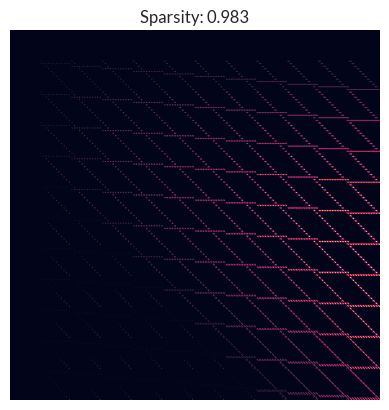

In [587]:
M, T = approximation(k_max, pars)
plt.imshow(M > 0, vmin = 0, vmax = 1)
plt.gca().axis("off")
t = plt.gca().set(title = f"Sparsity: {(M == 0).mean():.3f}")

## Edge Size Distribution Check

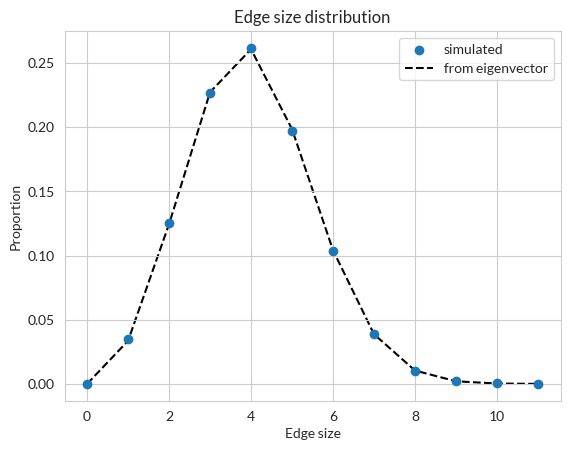

In [588]:
T_empirical = np.array([[[r[(i, j, k)] for k in range(k_max)] for j in range(k_max)] for i in range(k_max)])
T_empirical = T_empirical / T_empirical.sum()
T_empirical

empirical = 1/2*(T_empirical.sum(axis = (1, 2)) + T_empirical.sum(axis = (0, 2)))

theory = 1/2*(T[:,:,0].sum(axis = 1) + T[:,:,0].sum(axis = 0))
# theory_prop    = theory_prop / theory_prop[0]
theory = theory / theory.sum()

plt.scatter(np.arange(len(empirical)), empirical, label = "simulated")
plt.plot(np.arange(len(theory)), theory, color = "black", linestyle = "dashed", label = "from eigenvector", zorder = -1)

plt.legend()
labs = plt.gca().set(title = "Edge size distribution", xlabel = "Edge size", ylabel = "Proportion")

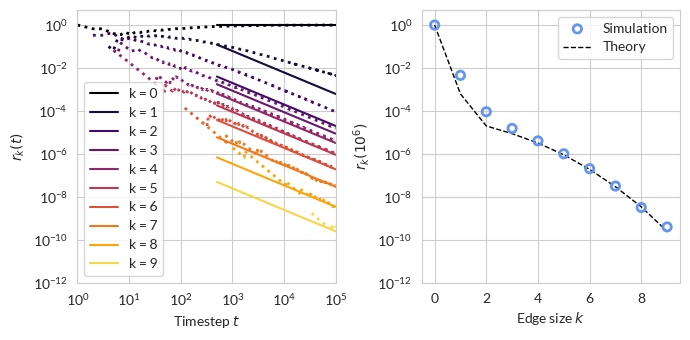

In [589]:
theory_prop    = T.sum(axis = (0,1))
theory_prop    = theory_prop / theory_prop[0]

q = theory_prop

k_min = 0
show_k_up_to = 10

import matplotlib.cm as cm
cmap = cm.inferno

fig, axarr = plt.subplots(1, 2, figsize = (7, 3.5))

# 1. plot slopes
ax = axarr.ravel()[0]
R_ = R / R.sum(axis = 1)[:, None]
R_[R_ == 0] = np.nan

for k in range(k_min, show_k_up_to): 
    try: 
        ax.plot(R_[    :, k], linestyle = ":", color = cmap(k/show_k_up_to), linewidth = 2)
    except: 
        pass

m_ = np.arange(5, 1000)*100 + 1

for k in range(k_min, show_k_up_to): 
    if k == 0: 
        ax.plot(m_, q[0]*np.ones_like(m_), label = f"k = {k}", color = cmap(k/show_k_up_to))
    else:    
        ax.plot(m_, q[k]*1/m_, label = f"k = {k}", color = cmap(k/show_k_up_to))

ax.loglog()

ax.legend(frameon=True)

ax.set(xlim = (1, timesteps), ylim = (1e-12, 5), xlabel = r"Timestep $t$", ylabel = r"$r_{k}(t)$")

T_empirical = np.array([[[r[(i, j, k)] for k in range(k_max)] for j in range(k_max)] for i in range(k_max)])
T_empirical = T_empirical / T_empirical.sum()

empirical_prop = T_empirical.sum(axis = (0, 1)) / T_empirical.sum()
theory_prop    = T.sum(axis = (0,1))
theory_prop    = theory_prop / theory_prop[0]
theory_prop[1:] = theory_prop[1:] / timesteps 
ix = empirical_prop > 0

ax = axarr.ravel()[1]
ax.scatter(np.array(range(k_max))[np.where(ix)], empirical_prop[ix], label = "Simulation", edgecolors="cornflowerblue", facecolor = "none", zorder = 10, linewidth=2)
ax.plot(np.array(range(k_max))[np.where(ix)], theory_prop[ix], label = "Theory", color = "black", linewidth = 1, linestyle = "dashed")
ax.legend()

ax.semilogy()
ax.set(ylim = (1e-12, 5), xlim = (-0.5, 9.5))
# ax.xlim(-0.1, 10.5)
ax.set(xlabel = r"Edge size $k$", ylabel = r"$r_k(10^6)$")

# this plot needs a separate colorbar

plt.tight_layout()

plt.savefig("../fig/intersection-asymptotics-2-panel.png", dpi = 300, bbox_inches = "tight")

In [590]:
empirical_prop/theory_prop

array([0.99534128, 7.35642769, 4.58399991, 1.75417192, 1.25520625,
       1.11353139, 1.07653684, 1.07453715, 0.92554562, 1.60501315,
       0.        , 0.        ])

## Fun Viz of Matrix Sparsity

This would be a nice candidate for making an art piece to commemorate the project! 

/var/folders/xn/wvbwvw0d6dx46h9_2bkrknnw0000gn/T/ipykernel_83710/1222403109.py:15: RuntimeWarning: divide by zero encountered in log
  M = np.log(M[k_max_*(k_max_+1):,k_max_*(k_max_+1):])


(np.float64(-0.5), np.float64(43.5), np.float64(43.5), np.float64(-0.5))

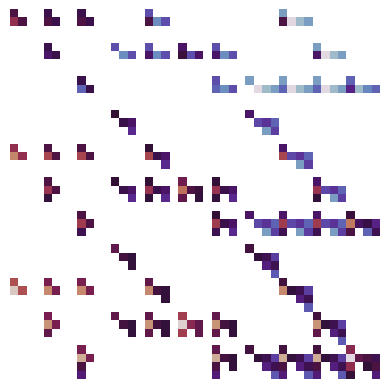

In [507]:
k_max_ = 4
pars = {
    "eta"   : 0.6, 
    "beta"  : np.zeros(k_max_),
    "gamma" : np.zeros(k_max_)
}

pars["beta"][0:7] = 1/7
pars["gamma"][0:7] = 1/7

eta, beta, gamma = pars["eta"], pars["beta"], pars["gamma"]

MC = m.MatrixConstructor(k_max_, pars)
M = MC.matrix_of_linear_map()
M = np.log(M[k_max_*(k_max_+1):,k_max_*(k_max_+1):])
plt.imshow(M, interpolation="none", cmap = "twilight")
plt.gca().axis("off")
